# Análisis, Limpieza, Balanceo y Fine-tuning de BERT
## Clasificación de Función de Cita Científica

Proceso:

1. **Análisis exploratorio de datos (EDA)**: distribución de clases, longitud
   de textos, duplicados, valores nulos.
2. **Limpieza de datos**: normalización de texto, eliminación de duplicados.
3. **Balanceo de categorías**: diagnóstico del desbalance y estrategia de
   corrección.
4. **Fine-tuning de BERT** (`bert-base-uncased`) sobre las
   9 categorías de función de cita.
5. **Evaluación**: reporte de clasificación, matriz de confusión, guardado
   del modelo final.



## 1. Importar librerías

In [1]:
!python --version

Python 3.12.12


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install transformers datasets torch scikit-learn pandas matplotlib seaborn accelerate mlflow --break-system-packages --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 114.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 116.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.6/144.6 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import StratifiedGroupKFold

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

import mlflow
import torch
import torch.nn as nn
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)


## 2. Configuración

In [5]:
BASE_NAME = "final_labelled_citing_sentences_all"
INPUT_CSV = Path(f"/content/drive/MyDrive/Colab Notebooks/microproyecto/data/{BASE_NAME}.csv")

TEXT_COL = "citing-sentence"
LABEL_COL = "label"

MODEL_NAME = "bert-base-uncased"
OUTPUT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/microproyecto/data/bert-citation-function")

# Umbrales de limpieza por longitud del texto (en caracteres)
MIN_TEXT_LENGTH = 15
MAX_TEXT_LENGTH = 2000

RANDOM_SEED = 42
set_seed(RANDOM_SEED)

# Configuración de MLflow
MLFLOW_TRACKING_URI = "http://54.161.116.231:8050"
MLFLOW_EXPERIMENT_NAME = "bert-citation-function2"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)


2026/09/22 03:14:56 INFO mlflow.tracking.fluent: Experiment with name 'bert-citation-function2' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/8', creation_time=1790046896736, effective_trace_archival_retention=None, experiment_id='8', last_update_time=1790046896736, lifecycle_stage='active', name='bert-citation-function2', tags={}, trace_location=None, workspace='default'>

## 3. Carga del dataset

In [6]:
if not INPUT_CSV.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo '{INPUT_CSV}'."
    )

df_raw = pd.read_csv(INPUT_CSV, dtype={"paper-id": str, "line-number": str})

print(f"Filas cargadas: {len(df_raw)}")
print(f"Columnas: {list(df_raw.columns)}")
df_raw.head(5)


Filas cargadas: 718304
Columnas: ['paper-id', 'published-date-in-ArXiv', 'paper-title', 'line-number', 'citing-sentence', 'label']


,paper-id,published-date-in-ArXiv,paper-title,line-number,citing-sentence,label
0,0704.0002,2008-12-13,Sparsity-certifying Graph Decompositions,10,"Our results provide a unifying framework for all the previously known special cases , including Nash-Williams-Tutte...",Evidence
1,0704.0002,2008-12-13,Sparsity-certifying Graph Decompositions,28,"Map-graphs may be equivalently defined ( see , eg , <citation> ) as having exactly one cycle per connected componen...",Background
2,0704.0002,2008-12-13,Sparsity-certifying Graph Decompositions,45,Tay <citation> used this condition to give a direct proof of Laman 's theorem and generalized the formula condition...,Identification of the Originator
3,0704.0002,2008-12-13,Sparsity-certifying Graph Decompositions,47,A pebble game algorithm was first proposed in <citation> as an elegant alternative to Hendrickson 's Laman graph al...,Identification of the Originator
4,0704.0002,2008-12-13,Sparsity-certifying Graph Decompositions,48,"Berg and Jordan <citation> , provided the formal analysis of the pebble game of <citation> and introduced the idea ...",Identification of the Originator


## 4. Análisis exploratorio (EDA)

### 4.1 Nulos, duplicados, tipos de dato

In [7]:
print("Info general del DataFrame:")
df_raw.info()

print("\nValores nulos por columna:")
print(df_raw.isnull().sum())

print(f"\nFilas totalmente duplicadas: {df_raw.duplicated().sum()}")
print(f"Duplicados exactos en '{TEXT_COL}': {df_raw[TEXT_COL].duplicated().sum()}")


Info general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 718304 entries, 0 to 718303
Data columns (total 6 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   paper-id                 718304 non-null  object
 1   published-date-in-ArXiv  718304 non-null  object
 2   paper-title              718304 non-null  object
 3   line-number              718304 non-null  object
 4   citing-sentence          718304 non-null  object
 5   label                    718304 non-null  object
dtypes: object(6)
memory usage: 32.9+ MB

Valores nulos por columna:
paper-id                   0
published-date-in-ArXiv    0
paper-title                0
line-number                0
citing-sentence            0
label                      0
dtype: int64

Filas totalmente duplicadas: 1814
Duplicados exactos en 'citing-sentence': 11079


### 4.2 Distribución de clases (label)

label
Identification of the Originator    243031
Application                         115215
Evidence                            113488
Basis                                55878
Background                           55508
Further Reading                      51987
Comparison                           39364
Improvement / Modification           28779
Gap                                  15054
Name: count, dtype: int64


/tmp/ipython-input-559594861.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.values, y=label_counts.index, palette="viridis")


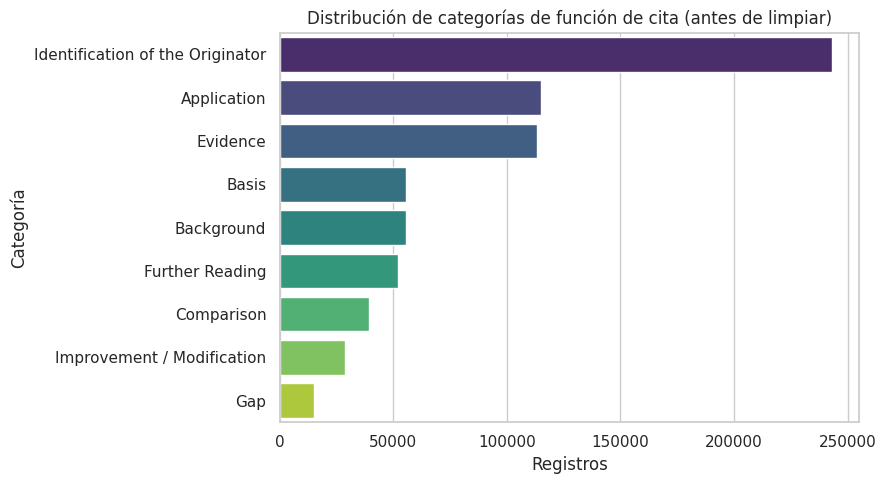


Ratio desbalance (clase mayoritaria / clase minoritaria): 16.14x


In [8]:
label_counts = df_raw[LABEL_COL].value_counts()
print(label_counts)

plt.figure(figsize=(9, 5))
sns.barplot(x=label_counts.values, y=label_counts.index, palette="viridis")
plt.title("Distribución de categorías de función de cita (antes de limpiar)")
plt.xlabel("Registros")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

print(f"\nRatio desbalance (clase mayoritaria / clase minoritaria): "
      f"{label_counts.max() / label_counts.min():.2f}x")


### 4.3 Distribución de longitud del texto

Estadísticas de longitud de texto (caracteres):
count    718304.000000
mean        184.653947
std          91.883999
min          16.000000
25%         123.000000
50%         166.000000
75%         223.000000
max        1703.000000
Name: text_length, dtype: float64


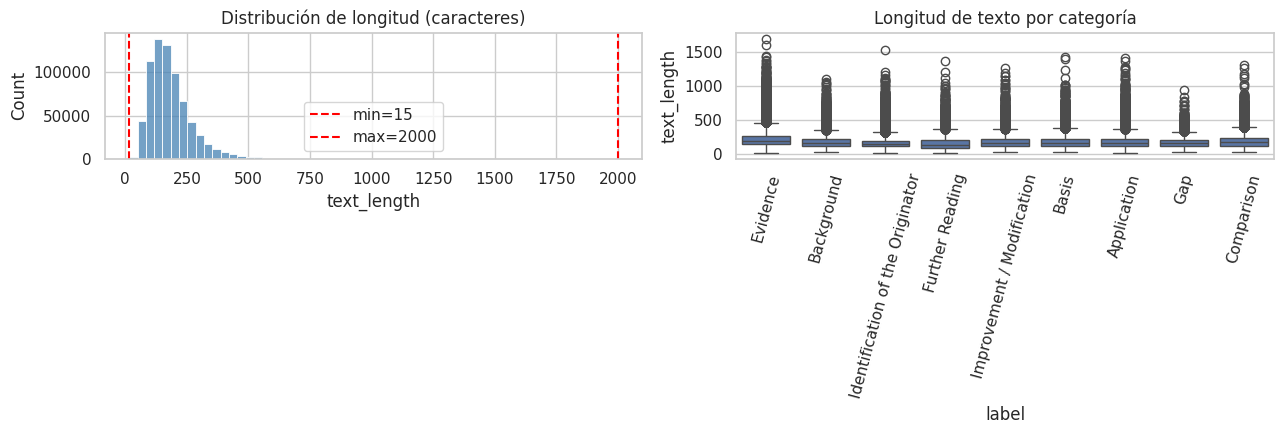


Registros con longitud < 15: 0
Registros con longitud > 2000: 0


In [9]:
df_raw["text_length"] = df_raw[TEXT_COL].astype(str).apply(len)
df_raw["word_count"] = df_raw[TEXT_COL].astype(str).apply(lambda t: len(t.split()))

print("Estadísticas de longitud de texto (caracteres):")
print(df_raw["text_length"].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df_raw["text_length"], bins=50, ax=axes[0], color="steelblue")
axes[0].axvline(MIN_TEXT_LENGTH, color="red", linestyle="--", label=f"min={MIN_TEXT_LENGTH}")
axes[0].axvline(MAX_TEXT_LENGTH, color="red", linestyle="--", label=f"max={MAX_TEXT_LENGTH}")
axes[0].set_title("Distribución de longitud (caracteres)")
axes[0].legend()

sns.boxplot(x=LABEL_COL, y="text_length", data=df_raw, ax=axes[1])
axes[1].set_title("Longitud de texto por categoría")
axes[1].tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()

print(f"\nRegistros con longitud < {MIN_TEXT_LENGTH}: "
      f"{(df_raw['text_length'] < MIN_TEXT_LENGTH).sum()}")
print(f"Registros con longitud > {MAX_TEXT_LENGTH}: "
      f"{(df_raw['text_length'] > MAX_TEXT_LENGTH).sum()}")


## 5. Limpieza de datos

Pasos aplicados:
1. Eliminar filas con texto o etiqueta nula/vacía.
2. Normalizar espacios en blanco (colapsar espacios múltiples, quitar saltos de línea sobrantes).
3. Eliminar duplicados exactos en `citing-sentence` (mismo texto + misma etiqueta).
4. Filtrar textos demasiado cortos (probable ruido/truncamiento) o demasiado largos (probable error de parseo).
5. Verificar que las etiquetas correspondan exactamente a las 9 categorías esperadas.

In [10]:
EXPECTED_LABELS = {
    "Background",
    "Further Reading",
    "Evidence",
    "Basis",
    "Application",
    "Improvement / Modification",
    "Identification of the Originator",
    "Gap",
    "Comparison",
}

def normalize_whitespace(text: str) -> str:
    text = str(text)
    text = text.replace("\n", " ").replace("\r", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


df = df_raw.copy()
n_inicial = len(df)

# 1. Nulos / vacíos
df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df = df[df[TEXT_COL].astype(str).str.strip() != ""]
n_tras_nulos = len(df)

# 2. Normalizar texto
df[TEXT_COL] = df[TEXT_COL].apply(normalize_whitespace)
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()

# 3. Duplicados exactos (texto + etiqueta)
df = df.drop_duplicates(subset=[TEXT_COL, LABEL_COL])
n_tras_duplicados = len(df)

# 4. Filtrar por longitud
df["text_length"] = df[TEXT_COL].apply(len)
df = df[(df["text_length"] >= MIN_TEXT_LENGTH) & (df["text_length"] <= MAX_TEXT_LENGTH)]
n_tras_longitud = len(df)

# 5. Verificar etiquetas válidas
etiquetas_invalidas = set(df[LABEL_COL].unique()) - EXPECTED_LABELS
if etiquetas_invalidas:
    print(f"ADVERTENCIA: etiquetas inesperadas encontradas: {etiquetas_invalidas}")
    df = df[df[LABEL_COL].isin(EXPECTED_LABELS)]
n_final = len(df)

print("Resumen:")
print(f"  Filas iniciales:                    {n_inicial}")
print(f"  Tras eliminar nulos/vacíos:         {n_tras_nulos}  (-{n_inicial - n_tras_nulos})")
print(f"  Tras eliminar duplicados:           {n_tras_duplicados}  (-{n_tras_nulos - n_tras_duplicados})")
print(f"  Tras filtrar por longitud:          {n_tras_longitud}  (-{n_tras_duplicados - n_tras_longitud})")
print(f"  Tras validar etiquetas:             {n_final}  (-{n_tras_longitud - n_final})")
print(f"\n  Total descartado: {n_inicial - n_final} filas ({(n_inicial - n_final) / n_inicial * 100:.1f}%)")

df = df.reset_index(drop=True)
df[[TEXT_COL, LABEL_COL]].head(10)


Resumen:
  Filas iniciales:                    718304
  Tras eliminar nulos/vacíos:         718304  (-0)
  Tras eliminar duplicados:           707225  (-11079)
  Tras filtrar por longitud:          707225  (-0)
  Tras validar etiquetas:             707225  (-0)

  Total descartado: 11079 filas (1.5%)


,citing-sentence,label
0,"Our results provide a unifying framework for all the previously known special cases , including Nash-Williams-Tutte ...",Evidence
1,"Map-graphs may be equivalently defined ( see , eg , <citation> ) as having exactly one cycle per connected component...",Background
2,Tay <citation> used this condition to give a direct proof of Laman 's theorem and generalized the formula condition ...,Identification of the Originator
3,A pebble game algorithm was first proposed in <citation> as an elegant alternative to Hendrickson 's Laman graph alg...,Identification of the Originator
4,"Berg and Jordan <citation> , provided the formal analysis of the pebble game of <citation> and introduced the idea o...",Identification of the Originator
5,"Lee and Streinu <citation> generalized the pebble game to the entire range of parameters formula , and left as an op...",Identification of the Originator
6,"Since the phrase `` with colors '' is necessary only for comparison to <citation> , we will omit it in the rest of t...",Further Reading
7,Our first result is a strengthening of the pebble games of <citation> to include colors,Improvement / Modification
8,These time and space bounds mean that our algorithm can be combined with those of <citation> without any change in c...,Improvement / Modification
9,Since many of the relevant properties of the pebble game with colors carry over directly from the pebble games of <c...,Further Reading


### 5.1 Distribución de clases después de la limpieza

label
Identification of the Originator    238687
Application                         113880
Evidence                            112211
Basis                                55141
Background                           54528
Further Reading                      50559
Comparison                           38904
Improvement / Modification           28446
Gap                                  14869
Name: count, dtype: int64


/tmp/ipython-input-3415060351.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts_clean.values, y=label_counts_clean.index, palette="mako")


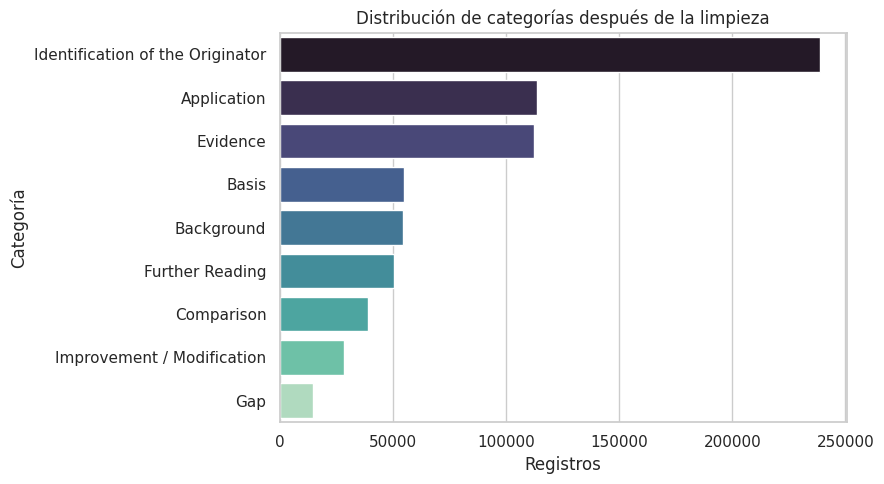

In [11]:
label_counts_clean = df[LABEL_COL].value_counts()
print(label_counts_clean)

plt.figure(figsize=(9, 5))
sns.barplot(x=label_counts_clean.values, y=label_counts_clean.index, palette="mako")
plt.title("Distribución de categorías después de la limpieza")
plt.xlabel("Registros")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()


## 6. Balanceo de categorías

El desbalance de clases es muy notorio, pero debido a la complejidad del texto aplicaremos la estratégia de balanceo **`class_weights`** donde penalizamos más el error en clases minoritarias durante el entrenamiento, ajustando la función de pérdida. Lo que nos permite evitar le riesgo de overfitting por duplicación de información.

In [12]:
# Estrategia de balanceo.
BALANCE_STRATEGY = "class_weights"

class_weights_tensor = None

df_balanced = df.copy()


## 7. Mapeo de etiquetas a IDs numéricos

In [13]:
labels_sorted = sorted(df_balanced[LABEL_COL].unique().tolist())
label2id = {label: idx for idx, label in enumerate(labels_sorted)}
id2label = {idx: label for label, idx in label2id.items()}
num_labels = len(labels_sorted)

print(f"Esquema de etiquetas ({num_labels} clases):")
for label, idx in label2id.items():
    print(f"  {idx}: {label}")

df_balanced["label_id"] = df_balanced[LABEL_COL].map(label2id)


Esquema de etiquetas (9 clases):
  0: Application
  1: Background
  2: Basis
  3: Comparison
  4: Evidence
  5: Further Reading
  6: Gap
  7: Identification of the Originator
  8: Improvement / Modification


## 8. División train / validation / test (estratificada)

In [14]:
TEST_SIZE = 0.15
EVAL_SIZE = 0.15

X = df_balanced
y = df_balanced["label_id"].values
groups = df_balanced["paper-id"].values

n_splits_test = round(1 / TEST_SIZE)  # 7 folds -> ~14.3% por fold
sgkf_test = StratifiedGroupKFold(n_splits=n_splits_test, shuffle=True, random_state=RANDOM_SEED)
trainval_idx, test_idx = next(sgkf_test.split(X, y, groups))

trainval_df = df_balanced.iloc[trainval_idx]
test_df = df_balanced.iloc[test_idx]

val_fraction_within_trainval = EVAL_SIZE / (1 - TEST_SIZE)
n_splits_val = round(1 / val_fraction_within_trainval)
sgkf_val = StratifiedGroupKFold(n_splits=n_splits_val, shuffle=True, random_state=RANDOM_SEED)

y_tv = trainval_df["label_id"].values
groups_tv = trainval_df["paper-id"].values

train_idx, val_idx = next(sgkf_val.split(trainval_df, y_tv, groups_tv))
train_df = trainval_df.iloc[train_idx]
val_df = trainval_df.iloc[val_idx]

print(f"Train:      {len(train_df)} ejemplos ({len(train_df) / len(df_balanced) * 100:.1f}%)")
print(f"Validation: {len(val_df)} ejemplos ({len(val_df) / len(df_balanced) * 100:.1f}%)")
print(f"Test:       {len(test_df)} ejemplos ({len(test_df) / len(df_balanced) * 100:.1f}%)")

# Verificación de que no hay papers compartidos entre splits (chequeo de fuga)
train_papers = set(train_df["paper-id"])
val_papers   = set(val_df["paper-id"])
test_papers  = set(test_df["paper-id"])

print("\nValidación de la intersección de los conjuntos de datos:")
print("Papers en train ∩ test:", len(train_papers & test_papers))
print("Papers en train ∩ val:", len(train_papers & val_papers))
print("Papers en val ∩ test:", len(val_papers & test_papers))
print("Total papers únicos:", len(train_papers | val_papers | test_papers))

# Verificación de que la distribución de clases se mantiene razonablemente similar entre splits
print("\nDistribución de clases por split (%):")
dist = pd.concat([
    train_df[LABEL_COL].value_counts(normalize=True).rename("train"),
    val_df[LABEL_COL].value_counts(normalize=True).rename("val"),
    test_df[LABEL_COL].value_counts(normalize=True).rename("test"),
], axis=1) * 100
print(dist.round(2))


Train:      503111 ejemplos (71.1%)
Validation: 102582 ejemplos (14.5%)
Test:       101532 ejemplos (14.4%)

Validación de la intersección de los conjuntos de datos:
Papers en train ∩ test: 0
Papers en train ∩ val: 0
Papers en val ∩ test: 0
Total papers únicos: 79551

Distribución de clases por split (%):
                                  train    val   test
label                                                
Identification of the Originator  33.56  34.03  34.41
Application                       16.13  16.16  15.92
Evidence                          15.90  15.95  15.60
Basis                              7.84   7.76   7.61
Background                         7.76   7.44   7.72
Further Reading                    7.15   7.20   7.09
Comparison                         5.52   5.45   5.49
Improvement / Modification         4.03   3.96   4.06
Gap                                2.11   2.05   2.11


## 9. Cálculo de pesos por clase

Los pesos se calculan **solo sobre el set de entrenamiento**, para no filtrar
información del set de validación/test hacia el proceso de entrenamiento.

In [15]:
weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_labels),
    y=train_df["label_id"].values,
)
class_weights_tensor = torch.tensor(weights_array, dtype=torch.float)

print("Pesos calculados por clase (mayor peso = clase más rara):")
for idx, w in enumerate(weights_array):
    print(f"  {id2label[idx]:40s} -> peso: {w:.3f}")


Pesos calculados por clase (mayor peso = clase más rara):
  Application                              -> peso: 0.689
  Background                               -> peso: 1.432
  Basis                                    -> peso: 1.417
  Comparison                               -> peso: 2.015
  Evidence                                 -> peso: 0.699
  Further Reading                          -> peso: 1.554
  Gap                                      -> peso: 5.261
  Identification of the Originator         -> peso: 0.331
  Improvement / Modification               -> peso: 2.759


## 9.1 Diagnóstico: longitud en tokens

Analizamos la cantidad de tokens necesaria para BERT tokenizando una muestra real del dataset para conocer la distribución exacta
en tokens.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Longitud en TOKENS (muestra de 20000 ejemplos):
  Percentil  50: 35.0 tokens
  Percentil  75: 47.0 tokens
  Percentil  90: 62.0 tokens
  Percentil  95: 73.0 tokens
  Percentil  99: 104.0 tokens
  Percentil 100: 264.0 tokens

  Media:  39.2 tokens
  Máximo: 264 tokens


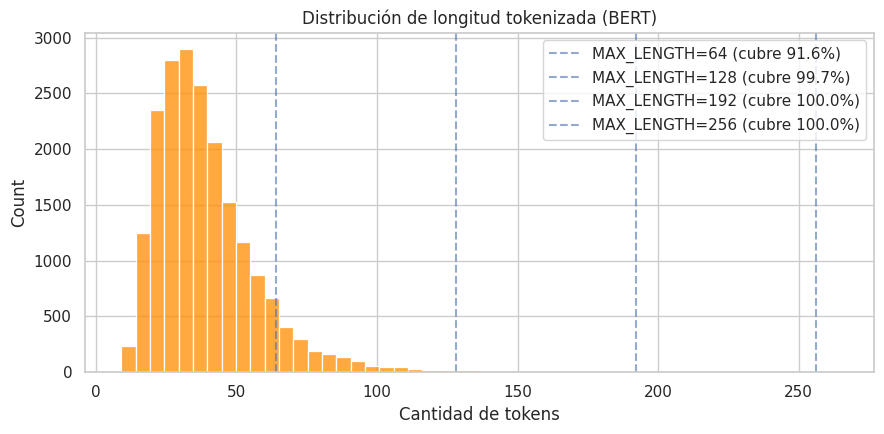

In [16]:
from transformers import AutoTokenizer

_diag_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Muestra para medir longitud real
sample_size = min(20000, len(df_balanced))
sample_texts = df_balanced[TEXT_COL].sample(sample_size, random_state=RANDOM_SEED).tolist()

token_lengths = [
    len(_diag_tokenizer.encode(t, add_special_tokens=True)) for t in sample_texts
]
token_lengths = np.array(token_lengths)

percentiles = [50, 75, 90, 95, 99, 100]
print(f"Longitud en TOKENS (muestra de {sample_size} ejemplos):")
for p in percentiles:
    print(f"  Percentil {p:>3}: {np.percentile(token_lengths, p):.1f} tokens")

print(f"\n  Media:  {token_lengths.mean():.1f} tokens")
print(f"  Máximo: {token_lengths.max()} tokens")

plt.figure(figsize=(9, 4.5))
sns.histplot(token_lengths, bins=50, color="darkorange")
for candidate in [64, 128, 192, 256]:
    pct_covered = (token_lengths <= candidate).mean() * 100
    plt.axvline(candidate, linestyle="--", alpha=0.6,
                label=f"MAX_LENGTH={candidate} (cubre {pct_covered:.1f}%)")
plt.title("Distribución de longitud tokenizada (BERT)")
plt.xlabel("Cantidad de tokens")
plt.legend()
plt.tight_layout()
plt.show()


## 10. Tokenización con BERT

Seleccionamos 128 porque cubre la mayoría de los casos según el análisis anterior y tiene un menor costo computacional que 256.

In [17]:
MAX_LENGTH = 128

print(f"Cargando tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def to_hf_dataset(pdf: pd.DataFrame) -> Dataset:
    return Dataset.from_pandas(
        pdf[[TEXT_COL, "label_id"]].rename(columns={TEXT_COL: "text", "label_id": "labels"})
    )


train_ds = to_hf_dataset(train_df)
val_ds = to_hf_dataset(val_df)
test_ds = to_hf_dataset(test_df)


def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=MAX_LENGTH)


train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds = val_ds.map(tokenize_fn, batched=True)
test_ds = test_ds.map(tokenize_fn, batched=True)

columns = ["input_ids", "attention_mask", "labels"]
train_ds.set_format(type="torch", columns=columns)
val_ds.set_format(type="torch", columns=columns)
test_ds.set_format(type="torch", columns=columns)

print("Tokenización completada.")


Cargando tokenizer: bert-base-uncased


Map:   0%|          | 0/503111 [00:00<?, ? examples/s]

Map:   0%|          | 0/102582 [00:00<?, ? examples/s]

Map:   0%|          | 0/101532 [00:00<?, ? examples/s]

Tokenización completada.


## 11. Modelo y Trainer

Se define la clase `WeightedTrainer` que sobreescribe el cálculo de la pérdida para
aplicar `class_weights`.

In [18]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo de entrenamiento: {device}")


class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        if self.class_weights is not None:
            loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        else:
            loss_fct = nn.CrossEntropyLoss()

        loss = loss_fct(logits.view(-1, num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_weighted": f1_w,
        "precision_weighted": precision_w,
        "recall_weighted": recall_w,
    }


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Dispositivo de entrenamiento: cuda


## 12. Configuración y ejecución del entrenamiento

In [ ]:
EPOCHS = 1
BATCH_SIZE = 16
LEARNING_RATE = 2e-5

steps_per_epoch = max(1, len(train_ds) // BATCH_SIZE)
total_steps = steps_per_epoch * EPOCHS
warmup_steps = int(0.1 * total_steps)

SAVE_STEPS = max(200, steps_per_epoch // 10)

print(f"Pasos por época: {steps_per_epoch}")
print(f"Pasos totales:   {total_steps}")
print(f"Warmup steps (10%): {warmup_steps}")
print(f"Guardando checkpoint cada {SAVE_STEPS} pasos")

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    warmup_steps=warmup_steps,
    eval_strategy="steps",
    eval_steps=SAVE_STEPS,
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    logging_strategy="steps",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    report_to=["mlflow"],
    seed=RANDOM_SEED,
)

mlflow_run = mlflow.start_run(run_name=f"bert-citfunc-seed{RANDOM_SEED}")
mlflow.log_params({
    "model_name": MODEL_NAME,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "max_length": MAX_LENGTH,
    "balance_strategy": BALANCE_STRATEGY,
    "train_size": len(train_df),
    "val_size": len(val_df),
    "test_size": len(test_df),
    "num_labels": num_labels,
    "random_seed": RANDOM_SEED,
})

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)


Pasos por época: 31444
Pasos totales:   943.3199999999999
Warmup steps (10%): 94
Guardando checkpoint cada 3144 pasos


In [20]:
import glob

existing_checkpoints = sorted(
    glob.glob(str(OUTPUT_DIR / "checkpoint-*")),
    key=lambda p: int(p.split("-")[-1]),
)

resume_from = existing_checkpoints[-1] if existing_checkpoints else None

if resume_from:
    print(f"Checkpoint previo encontrado, reanudando desde: {resume_from}")
else:
    print("No se encontraron checkpoints previos. Iniciando entrenamiento desde cero.")

print("\nIniciando fine-tuning de BERT...\n")
train_result = trainer.train(resume_from_checkpoint=resume_from)

print("\nEntrenamiento finalizado.")
print(train_result.metrics)

No se encontraron checkpoints previos. Iniciando entrenamiento desde cero.

Iniciando fine-tuning de BERT...



2026/09/22 03:17:50 ERROR mlflow.utils.async_logging.async_logging_queue: Run Id a35554d2529f43dcbaf96b21e729dbb8: Failed to log run data: Exception: INVALID_PARAMETER_VALUE: Changing param values is not allowed. Params were already logged='[{'key': 'max_length', 'old_value': '128', 'new_value': '20'}]' for run ID='a35554d2529f43dcbaf96b21e729dbb8'.


Step,Training Loss,Validation Loss



Entrenamiento finalizado.
{'train_runtime': 83.7431, 'train_samples_per_second': 180.234, 'train_steps_per_second': 11.273, 'total_flos': 993569787150336.0, 'train_loss': 1.0229046829676225, 'epoch': 0.03002067101287963}


## 13. Evaluación sobre el conjunto de test

In [21]:
test_predictions = trainer.predict(test_ds)
preds = np.argmax(test_predictions.predictions, axis=-1)
true_labels = test_predictions.label_ids

target_names = [id2label[i] for i in range(num_labels)]
report = classification_report(true_labels, preds, target_names=target_names, zero_division=0)

print("Reporte de clasificación (test):\n")
print(report)

# Métricas de test a MLflow
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    true_labels, preds, average="macro", zero_division=0
)
precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
    true_labels, preds, average="weighted", zero_division=0
)
mlflow.log_metrics({
    "test_accuracy": accuracy_score(true_labels, preds),
    "test_f1_macro": f1_macro,
    "test_precision_macro": precision_macro,
    "test_recall_macro": recall_macro,
    "test_f1_weighted": f1_w,
    "test_precision_weighted": precision_w,
    "test_recall_weighted": recall_w,
})
mlflow.log_text(report, "test_classification_report.txt")


Reporte de clasificación (test):

                                  precision    recall  f1-score   support

                     Application       0.85      0.88      0.87     16162
                      Background       0.87      0.90      0.88      7843
                           Basis       0.73      0.79      0.76      7727
                      Comparison       0.74      0.83      0.78      5570
                        Evidence       0.83      0.70      0.76     15839
                 Further Reading       0.88      0.94      0.91      7201
                             Gap       0.77      0.85      0.81      2139
Identification of the Originator       0.97      0.92      0.95     34933
      Improvement / Modification       0.63      0.85      0.72      4118

                        accuracy                           0.86    101532
                       macro avg       0.81      0.85      0.83    101532
                    weighted avg       0.87      0.86      0.86    101532



### 13.1 Matriz de confusión

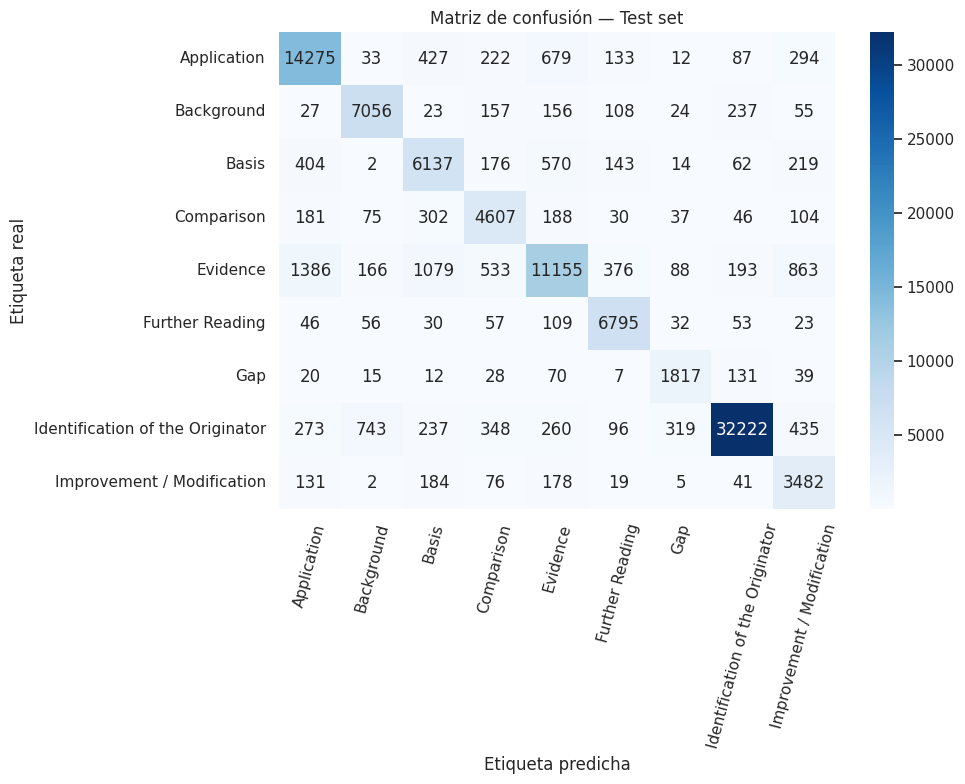

In [22]:
cm = confusion_matrix(true_labels, preds)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión — Test set")
plt.ylabel("Etiqueta real")
plt.xlabel("Etiqueta predicha")
plt.xticks(rotation=75)
plt.yticks(rotation=0)
plt.tight_layout()
mlflow.log_figure(plt.gcf(), "confusion_matrix.png")
plt.show()


## 14. Guardar modelo, tokenizer y metadatos

In [23]:
final_dir = OUTPUT_DIR / "model_bert_citing_sentences"
final_dir.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(final_dir))
tokenizer.save_pretrained(str(final_dir))

with open(final_dir / "label_mapping.json", "w", encoding="utf-8") as f:
    json.dump({"label2id": label2id, "id2label": id2label}, f, ensure_ascii=False, indent=2)

with open(final_dir / "test_classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

metadata = {
    "model_base": MODEL_NAME,
    "balance_strategy": BALANCE_STRATEGY,
    "max_length": MAX_LENGTH,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "train_size": len(train_df),
    "val_size": len(val_df),
    "test_size": len(test_df),
    "num_labels": num_labels,
}
with open(final_dir / "training_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"Modelo, tokenizer, mapeo de etiquetas y metadatos guardados en: {final_dir.resolve()}")

mlflow.log_artifacts(str(final_dir), artifact_path="model")
mlflow.end_run()
print(f"Run de MLflow registrado: {mlflow_run.info.run_id}")


Modelo, tokenizer, mapeo de etiquetas y metadatos guardados en: /content/drive/MyDrive/Colab Notebooks/microproyecto/data/bert-citation-function/model_bert_citing_sentences
🏃 View run bert-citfunc-seed42 at: http://54.161.116.231:8050/#/experiments/8/runs/a35554d2529f43dcbaf96b21e729dbb8
🧪 View experiment at: http://54.161.116.231:8050/#/experiments/8
Run de MLflow registrado: a35554d2529f43dcbaf96b21e729dbb8
